This is the code to generate analysis after we read the data and calculate the migration and widening rate for each oxbow lake. The first section is comparing the migration rate pre- and post cutoffs. We expect that the migration rate post cutoff may increase and then go back to about the pre-cutoff migration rate.

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob


After the modules are imported, we need to read file and generate parameters. Here our record lasts from 1984 to 2023. To make sure we have sufficient data both pre- and post cutoff, we set the minimum cutoff occurring year as 1990 and maximum cutoff occurring year as 2018 so that the filter is done.

Then we load the data from both "data_cutoff_with_slope.xlsx" and migration rate data from "Anylysis_Results".

In [6]:
# ==========================================
# 1. SETUP AND CONFIGURATION
# ==========================================

# File paths
master_file_path = "data_cutoff_with_slope.xlsx" # The master list
results_folder = "Analysis_Results"              # Folder containing individual cutoff files
sheet_name_master = "infill_rate"

# Parameters
MIN_CUTOFF_YEAR = 1990
MAX_CUTOFF_YEAR = 2018
MIN_YEARS_RECORD = 5      # Minimum data points required before AND after

# ==========================================
# 2. LOAD AND FILTER MASTER DATA
# ==========================================

# Load the master sheet
# User specified: Col A = Cutoff Number, Col D = Type, Col E = Year
# Pandas uses 0-based indexing: A=0, D=3, E=4
try:
    df_master = pd.read_excel(master_file_path, sheet_name=sheet_name_master, usecols=[0, 3, 4])
    df_master.columns = ['Cutoff_ID', 'Type', 'Cutoff_Year']
except Exception as e:
    print(f"Error loading master file: {e}")
    # Stop execution if master file fails
    raise

# Filter by Year Range (1990 - 2018)
# "if before 1990 we do not want it, if after 2018 we do not want it"
df_valid_years = df_master[
    (df_master['Cutoff_Year'] >= MIN_CUTOFF_YEAR) & 
    (df_master['Cutoff_Year'] <= MAX_CUTOFF_YEAR)
].copy()

print(f"Total cutoffs in target year range ({MIN_CUTOFF_YEAR}-{MAX_CUTOFF_YEAR}): {len(df_valid_years)}")

Total cutoffs in target year range (1990-2018): 192


After reading the data, we need to process it.

In [ ]:
# ==========================================
# 3. PROCESS MIGRATION RATES
# ==========================================

processed_data = []
valid_cutoff_count = 0

for index, row in df_valid_years.iterrows():
    c_id = row['Cutoff_ID']
    c_type = row['Type']
    c_year = row['Cutoff_Year']
    
    # Construct file path
    # Assuming files are named like "Cutoff_11.xlsx" or similar inside the folder
    # We use glob to find the file matching the ID to be robust
    search_pattern = os.path.join(results_folder, f"*{c_id}.xlsx")
    found_files = glob.glob(search_pattern)
    
    # Fallback: Check for .csv if .xlsx not found
    if not found_files:
        search_pattern = os.path.join(results_folder, f"*{c_id}.csv")
        found_files = glob.glob(search_pattern)
    
    if not found_files:
        print(f"Warning: No data file found for Cutoff ID {c_id}")
        continue
        
    file_path = found_files[0]
    
    try:
        # Load the individual cutoff file
        if file_path.endswith('.csv'):
            df_mig = pd.read_csv(file_path)
        else:
            df_mig = pd.read_excel(file_path)
            
        # Ensure column names match what we expect
        # Based on your sample: 'Start Year', 'End Year', 'Migration Speed (per year)'
        # We normalize column names to lowercase for safer matching
        df_mig.columns = [c.strip() for c in df_mig.columns]
        
        # Identify necessary columns
        start_year_col = next((c for c in df_mig.columns if 'start year' in c.lower()), None)
        end_year_col = next((c for c in df_mig.columns if 'end year' in c.lower()), None)
        rate_col = next((c for c in df_mig.columns if 'migration' in c.lower() and 'speed' in c.lower()), None)
        
        if not (start_year_col and end_year_col and rate_col):
            print(f"Skipping ID {c_id}: Could not find required columns (Start Year, End Year, Migration Speed).")
            continue

        # Split Data into Pre and Post
        # Logic: 
        # Pre-cutoff: The interval happened fully before or ended at the cutoff year.
        # Post-cutoff: The interval started strictly after the cutoff year.
        # This leaves a gap for the transition year (e.g. 2000-2001 if cutoff is 2000)
        
        df_pre = df_mig[df_mig[end_year_col] <= c_year]
        df_post = df_mig[df_mig[start_year_col] > c_year]
        
        # Check constraints: At least 5 years of record for both
        if len(df_pre) < MIN_YEARS_RECORD or len(df_post) < MIN_YEARS_RECORD:
            continue
            
        # 1. Average Pre-Cutoff Migration Rate
        m_pre = df_pre[rate_col].mean()
        
        if m_pre == 0: 
            continue # Avoid division by zero
            
        # 2. Process Post-Cutoff Bins (Every 3 years)
        # Calculate years since cutoff for the post dataset
        # If Cutoff=2000, StartYear=2001 -> Year 1
        df_post = df_post.copy()
        df_post['Years_Since'] = df_post[start_year_col] - c_year
        
        # Binning: (Year-1)//3 + 1 -> 1, 2, 3...
        df_post['Bin_ID'] = ((df_post['Years_Since'] - 1) // 3) + 1
        
        # Group by Bin and calculate mean
        bin_means = df_post.groupby('Bin_ID')[rate_col].mean()
        
        # Store results
        for bin_id, m_post_avg in bin_means.items():
            ratio = m_post_avg / m_pre
            
            # Label: 1~3, 4~6, etc.
            start_lbl = (bin_id - 1) * 3 + 1
            end_lbl = bin_id * 3
            label = f"{int(start_lbl)}~{int(end_lbl)}"
            
            processed_data.append({
                'Cutoff_ID': c_id,
                'Type': c_type,
                'Bin_ID': bin_id,
                'Bin_Label': label,
                'Ratio': ratio
            })
            
        valid_cutoff_count += 1
        
    except Exception as e:
        print(f"Error processing ID {c_id}: {e}")
        continue

df_results = pd.DataFrame(processed_data)
print(f"Analysis complete. Valid cutoffs processed: {valid_cutoff_count}")
print(f"Total data points for plotting: {len(df_results)}")



This is visualization code.

In [ ]:
# ==========================================
# 4. VISUALIZATION
# ==========================================

def plot_box_chart(data, title, filename_suffix):
    if data.empty:
        print(f"No data for {title}")
        return

    plt.figure(figsize=(12, 6))
    
    # Sort data by Bin_ID to ensure x-axis is 1~3, 4~6...
    data_sorted = data.sort_values('Bin_ID')
    
    # Box plot
    sns.boxplot(x='Bin_Label', y='Ratio', data=data_sorted, showfliers=False, color='lightblue')
    
    plt.title(title, fontsize=14)
    plt.xlabel("Years After Cutoff (3-Year Groups)", fontsize=12)
    plt.ylabel(r"Dimensionless Migration Rate ($M_{post}/M_{pre}$)", fontsize=12)
    plt.axhline(1, color='red', linestyle='--', linewidth=1.5, label='Baseline ($M_{pre}$)')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Save and Show
    # plt.savefig(f"migration_ratio_{filename_suffix}.png", dpi=300)
    plt.show()

# 1. All Data
plot_box_chart(df_results, "Post-Cutoff Migration Change (All Types)", "all")

# 2. Chute Only
df_chute = df_results[df_results['Type'].astype(str).str.lower().str.contains('chute')]
plot_box_chart(df_chute, "Post-Cutoff Migration Change (Chute Only)", "chute")

# 3. Neck Only
df_neck = df_results[df_results['Type'].astype(str).str.lower().str.contains('neck')]
plot_box_chart(df_neck, "Post-Cutoff Migration Change (Neck Only)", "neck")

In this analysis, we discussed if the cutoff behavior affects the migration rate 

In this section, we analyse if the cutoff will lead to the channel widening in the main channel. If the cutoff leads to widening, we may expect the widening value after cutoff as a positive value. Also we compare the widening rate between neck and chute cutoffs.

Starting Widening Analysis...
Widening analysis complete. 1072 data points generated.


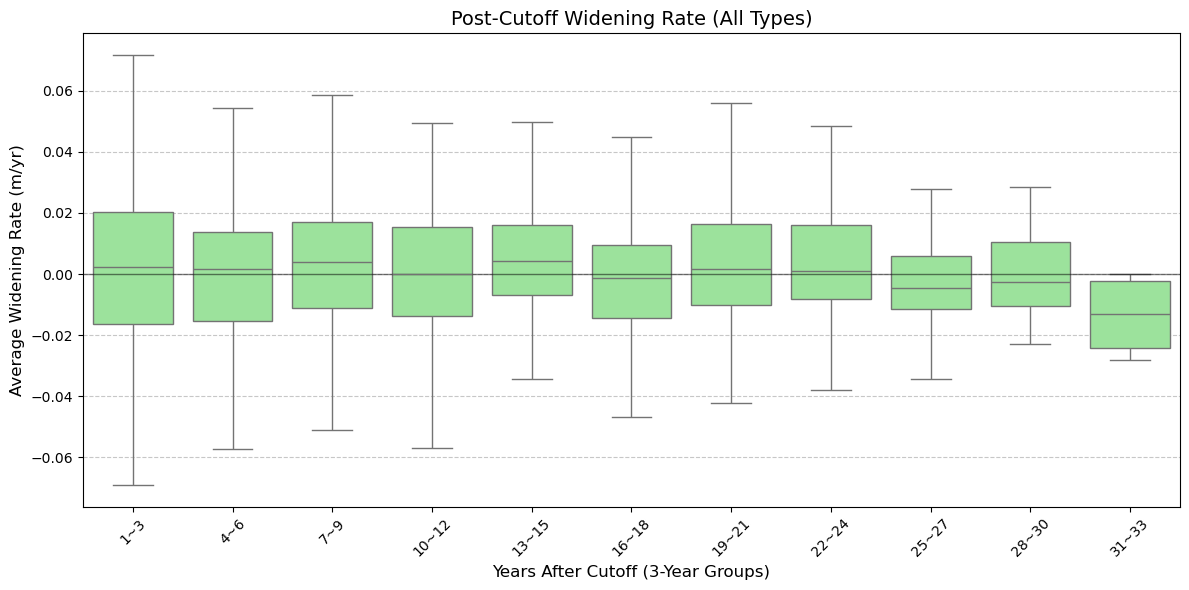

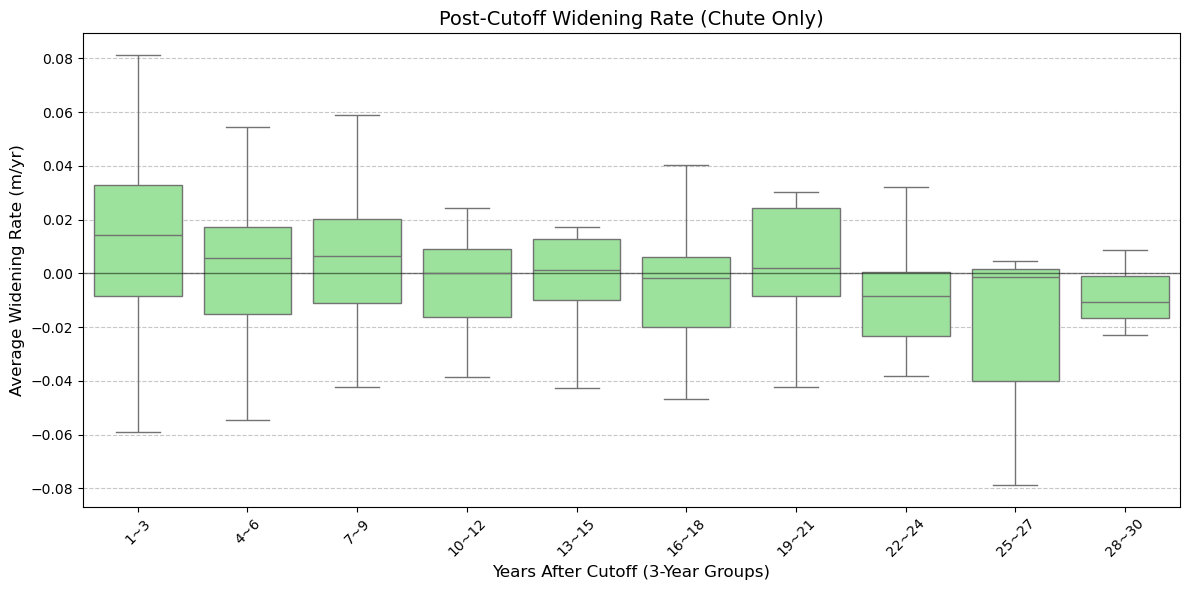

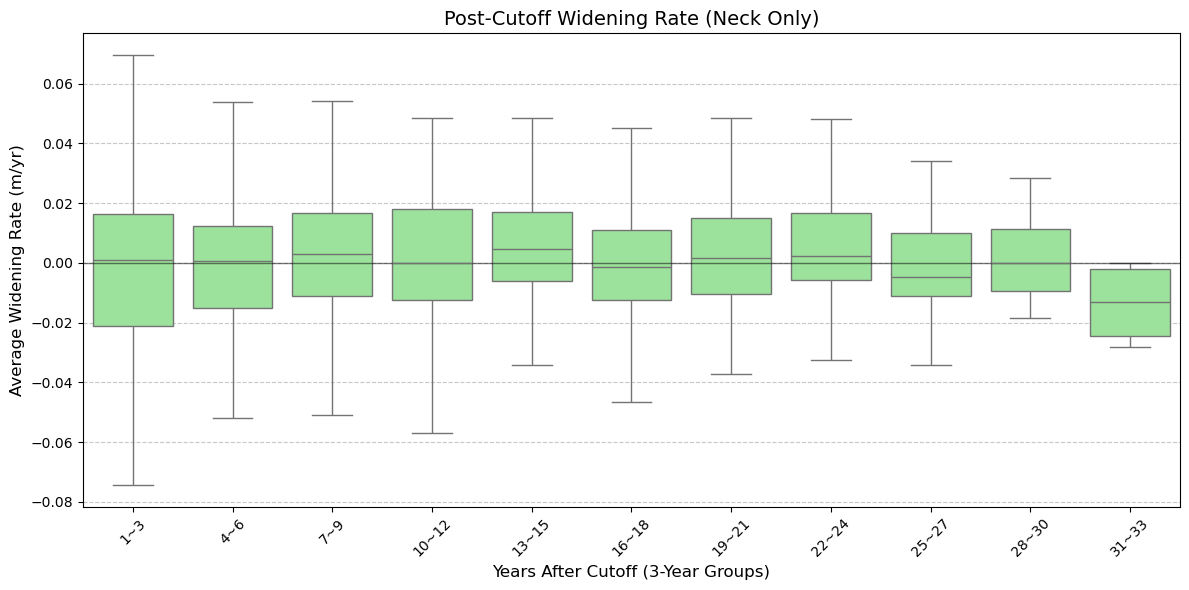

In [3]:
# ========================================================
# ANALYSIS PART 2: WIDENING RATE (Post-Cutoff Only)
# ========================================================

widening_data = []

print("Starting Widening Analysis...")

for index, row in df_valid_years.iterrows():
    c_id = row['Cutoff_ID']
    c_type = row['Type']
    c_year = row['Cutoff_Year']
    
    # 1. FIND FILE
    # (Using the same logic as before to locate the specific file)
    search_pattern = os.path.join(results_folder, f"*{c_id}.*") # Matches .csv or .xlsx
    found_files = glob.glob(search_pattern)
    
    if not found_files:
        continue
        
    file_path = found_files[0]
    
    try:
        # 2. LOAD DATA
        if file_path.endswith('.csv'):
            df_wide = pd.read_csv(file_path)
        else:
            df_wide = pd.read_excel(file_path)
            
        # Clean column names
        df_wide.columns = [c.strip().lower() for c in df_wide.columns]
        
        # Identify Columns
        # Looking for 'start year', 'end year', and 'widening rate'
        start_col = next((c for c in df_wide.columns if 'start year' in c), None)
        wide_col = next((c for c in df_wide.columns if 'widening' in c), None)
        
        if not (start_col and wide_col):
            continue

        # 3. FILTER POST-CUTOFF
        # We only want records where the interval starts AFTER the cutoff year
        df_post_wide = df_wide[df_wide[start_col] > c_year].copy()
        
        if df_post_wide.empty:
            continue

        # 4. GROUP BY 3-YEAR BINS
        # Calculate years elapsed since cutoff
        df_post_wide['Years_Since'] = df_post_wide[start_col] - c_year
        
        # Create Bin ID: (Year 1,2,3 -> Bin 1), (Year 4,5,6 -> Bin 2)
        df_post_wide['Bin_ID'] = ((df_post_wide['Years_Since'] - 1) // 3) + 1
        
        # 5. AVERAGE WIDENING RATE
        # We group by the bin and take the mean of the widening rate
        grouped_wide = df_post_wide.groupby('Bin_ID')[wide_col].mean()
        
        # Store Data
        for bin_id, avg_rate in grouped_wide.items():
            # Create readable label (e.g., "1~3")
            start_lbl = int((bin_id - 1) * 3 + 1)
            end_lbl = int(bin_id * 3)
            label = f"{start_lbl}~{end_lbl}"
            
            widening_data.append({
                'Cutoff_ID': c_id,
                'Type': c_type,
                'Bin_ID': bin_id,
                'Bin_Label': label,
                'Widening_Rate': avg_rate
            })
            
    except Exception as e:
        print(f"Error processing ID {c_id}: {e}")
        continue

# Create DataFrame
df_widening_results = pd.DataFrame(widening_data)
print(f"Widening analysis complete. {len(df_widening_results)} data points generated.")

# ========================================================
# PLOTTING WIDENING RATES
# ========================================================

def plot_widening_box(data, title):
    if data.empty:
        print(f"No data for {title}")
        return

    plt.figure(figsize=(12, 6))
    
    # Sort by Bin_ID to ensure x-axis order (1~3, 4~6...)
    data_sorted = data.sort_values('Bin_ID')
    
    sns.boxplot(x='Bin_Label', y='Widening_Rate', data=data_sorted, showfliers=False, color='lightgreen')
    
    plt.title(title, fontsize=14)
    plt.xlabel("Years After Cutoff (3-Year Groups)", fontsize=12)
    plt.ylabel("Average Widening Rate (m/yr)", fontsize=12)
    
    # Add a zero line (Separating Widening from Narrowing)
    plt.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 1. All Data
plot_widening_box(df_widening_results, "Post-Cutoff Widening Rate (All Types)")

# 2. Chute Only
df_chute_wide = df_widening_results[df_widening_results['Type'].astype(str).str.lower().str.contains('chute')]
plot_widening_box(df_chute_wide, "Post-Cutoff Widening Rate (Chute Only)")

# 3. Neck Only
df_neck_wide = df_widening_results[df_widening_results['Type'].astype(str).str.lower().str.contains('neck')]
plot_widening_box(df_neck_wide, "Post-Cutoff Widening Rate (Neck Only)")